# 🧠 Memória em Agentes de IA
Disciplina: GENERATIVE AI & ADAVANCED NETS  
Curso: Tecnólogo em Inteligência Artificial

## 📌 Objetivos de Aprendizagem

## Episódica, Semântica e Procedural

### Demonstração incremental com Gemini no Google Colab

A ideia é **observar o que muda na resposta de um LLM quando damos a ele diferentes tipos de memória**.

Vamos usar sempre o mesmo problema, o mesmo modelo e praticamente o mesmo prompt. A única coisa que muda entre os experimentos será a memória disponibilizada.

**Pergunta central:**

> Se o agente recebe mais memória, o que exatamente ele ganha?

> E por que uma memória semântica não substitui uma episódica ou uma procedural?

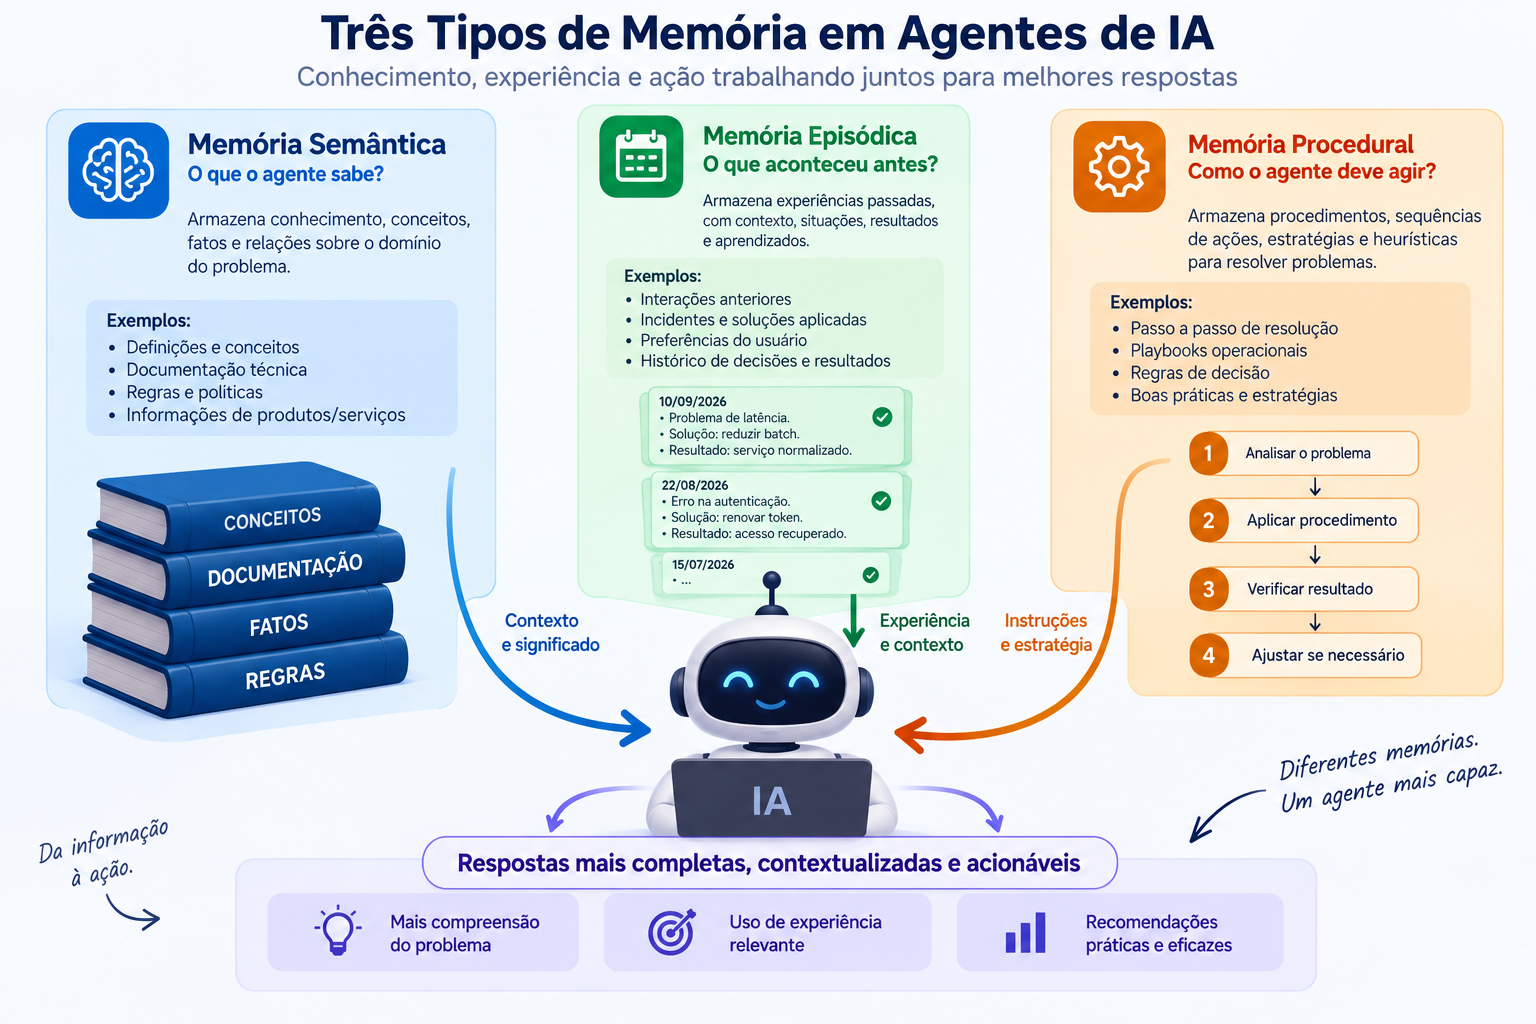

## 1. O cenário: um agente de suporte técnico para uma plataforma de IA

Imagine que estamos construindo um agente para ajudar uma equipe que usa uma **API de embeddings**.

O agente recebe o seguinte incidente:

> **A API começou a retornar HTTP 429 e a latência aumentou depois que aumentamos o `batch size` de 8 para 32 e a concorrência de 4 para 12. O que devemos fazer agora?**

Esse cenário é interessante porque exige três coisas diferentes:

- **Memória semântica:** saber o que significa 429, rate limit, retry, backoff, concorrência etc.
- **Memória episódica:** lembrar o que aconteceu em incidentes anteriores da própria equipe.
- **Memória procedural:** saber qual sequência de ações deve ser seguida para tratar o incidente.

A hipótese da aula é simples:

> **Os três tipos de memória não guardam a mesma coisa e, por isso, não produzem o mesmo tipo de melhoria na resposta.**

In [ ]:
# Contexto que permanecerá igual em todos os experimentos.

INCIDENT = """
A API de embeddings começou a retornar HTTP 429 e a latência aumentou
logo depois que aumentamos o batch size de 8 para 32 e a concorrência
simultânea de 4 para 12.

O operador pergunta: O que devemos fazer agora?
""".strip()

print(INCIDENT)

## 2. As três memórias: não são três versões da mesma informação

Vamos representar cada uma como um conjunto de informações recuperáveis.

### 🧠 Memória semântica — **o que é verdade?**

Conhecimento relativamente estável sobre conceitos, fatos e relações.

Exemplos:
- HTTP 429 significa que uma política de limite de requisições foi atingida.
- Aumentar concorrência pode aumentar a pressão sobre uma API.
- Exponential backoff é uma estratégia comum de recuperação.

### 🕘 Memória episódica — **o que aconteceu?**

Registros de experiências concretas, com contexto temporal e consequências.

Exemplo:
- Em um incidente anterior, a mesma equipe teve 429 ao aumentar o batch.
- Reduzir o batch e a concorrência resolveu o problema.
- A mudança foi feita em um contexto específico daquela operação.

### ⚙️ Memória procedural — **como devemos agir?**

Conhecimento operacional sobre sequência de ações, regras e políticas.

Exemplo:
1. Confirmar o rate limit.
2. Verificar `Retry-After`.
3. Reduzir pressão sobre a API.
4. Aplicar backoff.
5. Monitorar.
6. Restaurar carga gradualmente.

A diferença mais importante é:

> **Semântica responde “o que é?”. Episódica responde “o que aconteceu antes?”. Procedural responde “como agir?”.**

In [ ]:
# ---------------------------------
# 1) MEMÓRIA SEMÂNTICA
# ---------------------------------
semantic_memory = [
    "HTTP 429 Too Many Requests indica que o consumidor atingiu um limite de requisições imposto pelo serviço.",
    "Aumentar concorrência e batch size pode aumentar a taxa de requisições e a pressão sobre uma API.",
    "Exponential backoff reduz gradualmente a frequência das tentativas após falhas temporárias.",
    "Quando disponível, o header Retry-After pode indicar quanto tempo esperar antes de tentar novamente.",
]

# ---------------------------------
# 2) MEMÓRIA EPISÓDICA
# ---------------------------------
episodic_memory = [
    {
        "date": "2026-09-10",
        "event": "A API de embeddings da equipe começou a retornar 429 após aumento de batch e concorrência.",
        "action": "O batch voltou de 32 para 8 e a concorrência foi reduzida de 12 para 3.",
        "result": "As respostas 429 desapareceram e a latência voltou ao patamar observado antes do incidente.",
    },
    {
        "date": "2026-08-28",
        "event": "Uma tentativa de recuperar a carga apenas aumentando retries gerou ainda mais pressão sobre a API.",
        "action": "A equipe interrompeu retries agressivos e passou a usar backoff.",
        "result": "A taxa de erros caiu após a redução da frequência de novas tentativas.",
    },
]

# ---------------------------------
# 3) MEMÓRIA PROCEDURAL
# ---------------------------------
procedural_memory = [
    "Diante de HTTP 429, primeiro confirmar que a limitação é de taxa e verificar Retry-After quando disponível.",
    "Reduzir temporariamente batch size e concorrência para diminuir a pressão sobre o serviço.",
    "Aplicar retries com exponential backoff em vez de repetir imediatamente.",
    "Monitorar taxa de 429 e latência antes de restaurar a carga.",
    "Restaurar batch e concorrência gradualmente e em pequenos passos.",
]

print(f"Semântica: {len(semantic_memory)} registros")
print(f"Episódica: {len(episodic_memory)} episódios")
print(f"Procedural: {len(procedural_memory)} regras")

## 3. Vamos usar o Gemini apenas como observador do efeito da memória

Como o Gemini já foi usado nas aulas anteriores, aqui não vamos ensinar como configurar um modelo.

Vamos apenas fazer a infraestrutura mínima:

- recuperar `GOOGLE_API_KEY` dos **Colab Secrets**;
- usar `ChatGoogleGenerativeAI`;
- aplicar um `InMemoryRateLimiter` de **0,2 requisição/s**;
- usar o mesmo modelo e temperatura em todos os cenários.

Assim, nosso experimento fica controlado.

In [ ]:
# Instalação mínima para a demonstração.
!pip -q install -U langchain-core langchain-google-genai

import os
from typing import Optional
from IPython.display import display, Markdown

from google.colab import userdata
from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
# Configuração do Gemini usando o padrão já conhecido pela turma.

MODEL_PROVIDER = "gemini"
GEMINI_MODEL = "gemini-3.5-flash-lite"

def get_colab_secret(name: str) -> Optional[str]:
    try:
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    return os.getenv(name)

GOOGLE_API_KEY = get_colab_secret("GOOGLE_API_KEY")

if not GOOGLE_API_KEY:
    raise RuntimeError(
        "GOOGLE_API_KEY não encontrada. Adicione a chave aos Colab Secrets."
    )

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.2,
    check_every_n_seconds=0.1,
    max_bucket_size=1,
)

llm = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    temperature=0.2,
    google_api_key=GOOGLE_API_KEY,
    rate_limiter=rate_limiter,
    max_retries=0,
)

print("✅ Gemini configurado com rate limiter (0,2 req/s).")

## 4. Uma única função para montar o “cérebro” do agente

Agora vem uma ideia importante:

O LLM não muda.

O incidente não muda.

O que muda é **qual memória foi recuperada e inserida no contexto antes da geração**.

Isso nos permite fazer uma comparação didática muito mais limpa.

In [ ]:
# TODO crie uma função format_episodic_memory() para transformar a memória episódica
# em um único texto formatado, com uma linha para cada memória.
def format_episodic_memory():

    # TODO use "\n".join() para unir as memórias, colocando cada item em uma nova linha.
    # TODO para cada item de episodic_memory, formate:
    # "- data: evento | Ação: ação | Resultado: resultado"
    # TODO use item["date"], item["event"], item["action"] e item["result"]
    # para acessar as informações armazenadas em cada memória.
    return ...

In [ ]:
# TODO crie a função build_memory_context() para selecionar e organizar
# os diferentes tipos de memória que serão disponibilizados ao LLM.
# TODO use três parâmetros booleanos: use_semantic, use_episodic e use_procedural.
def build_memory_context(use_semantic=False, use_episodic=False, use_procedural=False):

    sections = []

    # TODO se use_semantic=True, adicione à lista sections a seção
    # "MEMÓRIA SEMÂNTICA" seguida dos itens de semantic_memory,
    # colocando cada item em uma nova linha com "- " no início.
    if use_semantic:
        ...

    # TODO se use_episodic=True, adicione à lista sections a seção
    # "MEMÓRIA EPISÓDICA" seguida do texto produzido por format_episodic_memory().
    if use_episodic:
        ...

    # TODO se use_procedural=True, adicione à lista sections a seção
    # "MEMÓRIA PROCEDURAL" seguida dos itens de procedural_memory,
    # colocando cada item em uma nova linha com "- " no início.
    if use_procedural:
        ...

    if not sections:
        return "Nenhuma memória externa foi disponibilizada."

    return "\n\n".join(sections)

In [ ]:
def build_prompt(use_semantic=False, use_episodic=False, use_procedural=False):
    memory_context = build_memory_context(
        use_semantic=use_semantic,
        use_episodic=use_episodic,
        use_procedural=use_procedural,
    )

    return f"""
Você é um agente de suporte técnico para uma plataforma de IA.

Responda à pergunta do operador usando SOMENTE:
1. seu conhecimento geral, e
2. as memórias explicitamente fornecidas abaixo.

Não invente experiências ou políticas que não estejam no contexto.

INCIDENTE:
{INCIDENT}

MEMÓRIAS DISPONÍVEIS:
{memory_context}

Responda em português.
Seja objetivo, mas explique a razão da recomendação.
Deixe claro o que você sabe conceitualmente, o que vem de experiência anterior
quando houver, e qual sequência prática recomenda quando houver memória procedural.
""".strip()

In [ ]:
def run_demo(title, use_semantic=False, use_episodic=False, use_procedural=False):

    # TODO construa o prompt usando build_prompt() e passe os três parâmetros
    # de memória recebidos pela função.
    prompt = ...

    # TODO envie o prompt para o LLM usando llm.invoke()
    # e armazene a resposta em response.
    response = ...

    print(f"### {title}")
    print("Memórias usadas:", end=" ")
    active = []
    if use_semantic:
        active.append("Semântica")
    if use_episodic:
        active.append("Episódica")
    if use_procedural:
        active.append("Procedural")
    print(", ".join(active) if active else "Nenhuma")

    display(Markdown(response.text))
    return response

# 🔬 Experimento 1 — Sem memória

Primeiro, vamos remover as três memórias.

O LLM ainda possui conhecimento geral adquirido durante seu pré-treinamento. Portanto, ele consegue reconhecer o erro HTTP 429 e sugerir soluções conhecidas, mesmo sem receber informações externas.

O objetivo aqui é observar o limite desse conhecimento quando o agente não recebe contexto específico do sistema.

In [ ]:
response_no_memory = run_demo(
    "Cenário 1 — Sem memória",
    use_semantic=False,
    use_episodic=False,
    use_procedural=False,
)

### O que observar

A resposta tende a ser genérica: o modelo pode explicar o significado de 429 e sugerir estratégias conhecidas, como reduzir a frequência de requisições ou utilizar retry com backoff.

O ponto principal é:

O modelo sabe sobre rate limiting, mas não sabe o que aconteceu com esta equipe, quais intervenções já foram realizadas ou qual procedimento operacional deve ser seguido.

Neste cenário, temos conhecimento geral, mas não temos memória específica do agente.

# 🔬 Experimento 2 — Adicionando apenas memória semântica

Agora fazemos uma única mudança: fornecemos ao modelo **conhecimento técnico estruturado sobre o sistema.**

Não fornecemos histórico de incidentes e ainda não fornecemos um procedimento operacional.

A pergunta continua exatamente a mesma.

In [ ]:
response_semantic = run_demo(
    "Cenário 2 — Memória semântica",
    use_semantic=True,
    use_episodic=False,
    use_procedural=False,
)

### O que mudou?

Compare a resposta com o cenário anterior.

Agora o modelo recebeu informações específicas sobre:

- o significado de HTTP 429 no contexto da aplicação;
- a relação entre concorrência, batch e pressão sobre a API;
- mecanismos como Retry-After e backoff.

A diferença é importante:

> A memória semântica fornece fatos, conceitos e relações que o agente pode utilizar para interpretar o problema.

Ela ajuda principalmente a responder perguntas como:

>“O que é isso?”

>“Por que isso acontece?”

Mas ainda falta uma informação:

>“O que aconteceu anteriormente neste sistema?”

Para isso, precisamos de memória episódica.

# 🔬 Experimento 3 — Semântica + Episódica

Agora adicionamos uma segunda camada: **memória episódica**.

A memória semântica continua exatamente igual.

A novidade é que o agente passa a ter acesso a **experiências anteriores do próprio sistema.**

In [ ]:
response_semantic_episodic = run_demo(
    "Cenário 3 — Memória semântica + episódica",
    use_semantic=True,
    use_episodic=True,
    use_procedural=False,
)

### O que a memória episódica acrescentou?

Aqui esperamos uma mudança especialmente importante: **a recomendação deixa de ser apenas genérica e passa a ser contextualizada pela experiência anterior**.

Agora o agente pode recuperar informações como:

- o episódio de 10/09;
- a redução de batch de 32 para 8;
- a redução de concorrência de 12 para 3;
- o fato de essa intervenção ter sido associada à recuperação do serviço.

A diferença fundamental é:

>A memória episódica permite recuperar acontecimentos específicos e utilizar essas experiências como contexto para a decisão atual.

Assim, o agente deixa de responder apenas com base em conhecimento técnico e passa a considerar também:

>“O que aconteceu conosco quando enfrentamos algo parecido?”

Perceba que isso não significa necessariamente que o modelo foi treinado novamente. A experiência está sendo **recuperada e utilizada como contexto durante a resposta.**

# 🔬 Experimento 4 — Semântica + Procedural

Agora vamos retirar a memória episódica e, em seu lugar, adicionar a **memória procedural**.

Assim podemos comparar duas coisas muito diferentes:

- **episódio** = o que aconteceu em situações anteriores (“já vimos isso acontecer e sabemos o que ocorreu”);
- **procedimento** = como devemos agir diante de uma situação (“quando isso acontece, siga esta sequência de ações”).

In [ ]:
response_semantic_procedural = run_demo(
    "Cenário 4 — Memória semântica + procedural",
    use_semantic=True,
    use_episodic=False,
    use_procedural=True,
)

### O que a memória procedural acrescentou?

Observe principalmente a **ordem da resposta**.

Com memória procedural, esperamos algo mais próximo de um playbook:

1. verificar o rate limit e `Retry-After`;
2. reduzir a pressão sobre a API;
3. controlar retries com backoff;
4. monitorar o comportamento;
5. restaurar carga gradualmente.

Perceba a diferença:

> **A memória episódica traz contexto de experiências passadas. A memória procedural traz uma política de ação.**

Uma equipe pode ter um procedimento excelente mesmo sem ter vivido ainda aquele incidente específico.

# 🔬 Experimento 5 — As três memórias juntas

Finalmente, combinamos:

**Semântica + Episódica + Procedural**.

Agora o LLM tem acesso a:

- conhecimento técnico;
- experiências anteriores;
- regras e sequência operacional.

A pergunta continua sendo a mesma.

In [ ]:
response_all_memory = run_demo(
    "Cenário 5 — Semântica + episódica + procedural",
    use_semantic=True,
    use_episodic=True,
    use_procedural=True,
)

## 5. O que a combinação muda?

Aqui está a ideia central da aula:

| Tipo de memória | Pergunta que ajuda a responder | O que acrescenta |
|---|---|---|
| **Semântica** | “O que é isso? Por que acontece?” | conhecimento técnico e conceitos |
| **Episódica** | “O que aconteceu antes?” | contexto, histórico e experiências |
| **Procedural** | “Como devemos agir?” | sequência, regras e política operacional |

Quando combinamos as três, o agente pode produzir uma resposta que é simultaneamente:

- **tecnicamente fundamentada**;
- **contextualizada pela experiência da própria organização**;
- **orientada à ação**.

Isso explica por que simplesmente dizer “o agente tem memória” é insuficiente.


> **O tipo de memória determina o tipo de informação que pode reaparecer no momento da decisão.**

>“Memória” não é uma única coisa. Diferentes tipos de memória fornecem diferentes tipos de informação para a tomada de decisão do agente.

# 🧩 6. Visualizando a arquitetura conceitual

Uma forma simples de pensar em um agente com memória é:

```text
                         ┌──────────────────────┐
                         │       Pergunta       │
                         └──────────┬───────────┘
                                    │
                                    ▼
                         ┌──────────────────────┐
                         │ Recuperação de       │
                         │ memória relevante    │
                         └──────────┬───────────┘
                                    │
             ┌──────────────────────┼──────────────────────┐
             │                      │                      │
             ▼                      ▼                      ▼
      ┌─────────────┐        ┌─────────────┐        ┌─────────────┐
      │ Semântica   │        │ Episódica   │        │ Procedural  │
      │ O que é?    │        │ O que houve?│        │ Como agir?  │
      └──────┬──────┘        └──────┬──────┘        └──────┬──────┘
             │                      │                      │
             └──────────────────────┼──────────────────────┘
                                    ▼
                         ┌──────────────────────┐
                         │        LLM           │
                         │ raciocínio + geração │
                         └──────────┬───────────┘
                                    │
                                    ▼
                         ┌──────────────────────┐
                         │ resposta / ação      │
                         └──────────────────────┘
```

A arquitetura real pode ser muito mais sofisticada — banco vetorial, filtros temporais, reranking, memória de longo prazo, grafos, sumarização etc.

Mas a distinção conceitual continua sendo a mesma.

# 🎯 7. Fechamento da demonstração

O ponto desta aula não é decorar três definições.

É perceber **por que os agentes precisam de tipos diferentes de memória**.

### Semântica
Sem ela, o agente pode perder conhecimento técnico específico que queremos disponibilizar explicitamente no contexto.

### Episódica
Sem ela, o agente pode conhecer a teoria, mas não consegue usar experiências concretas da própria operação.

### Procedural
Sem ela, o agente pode saber muito sobre o problema, mas não necessariamente saber **qual sequência de ações deve seguir**.

### Juntas
As três permitem que o mesmo sistema:

> **entenda o problema → relembre experiências relevantes → siga uma forma de agir.**

Essa separação é especialmente importante em arquiteturas modernas de agentes, porque “memória” não é um único bloco. É uma coleção de mecanismos com funções diferentes.